# Классификация жителей Сомервилля
**Автор:** Топорова Е.В.  
**Дата:** 23.10.2025
## Цель и задачи работы
Цель: изучение методов решения задачи классификации.

Задачи:
1. Выбрать массив данных, описать параметры. Примечание: тип задачи «классификация».
2. Провести дескриптивный анализ, определить, согласуются ли выборки с нормальным распределением.
3. Решить задачу классификации двумя методами (нейронная сеть, дерево решений, метод опорных векторов, дискриминантная функция и т.д.). Аргументировать выбор метода. Допустимо использовать две нейронные сети разных типов.
4. Оценить качество построенных моделей (в т.ч. точность, полноту классификатора). Провести сравнительный анализ решений.
5. Изменить параметры одного из методов (или параметры нейросети), оценить полученные результаты.
6. Интерпретировать результаты.

## Описание данных
Для выполнения работы был выбран датасет `Somerville Happiness Survey`. Каждые два года город Сомервилль отправляет опрос о счастье случайной выборке своих жителей. В опросе жителей просят оценить свое личное счастье, благополучие и удовлетворенность городскими услугами. Этот объединенный набор данных включает результаты опросов со случайной выборкой с 2011 по 2015 год.

Параметры:
- D – атрибут принятия решения со значениями 0 (несчастливый) и 1 (счастливый);
- X1 – доступность информации о городских услугах;
- X2 – стоимость жилья;
- X3 – общее качество государственных школ;
- X4 – доверие к местной полиции;
- X5 – содержание улиц и тротуаров;
- X6 – доступность социальных мероприятий сообщества.

Атрибуты от X1 до X6 имеют значения от 1 до 5.

---
## 1 Загрузка данных и знакомство с ними

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree, DecisionTreeClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, 
classification_report, accuracy_score, precision_score, recall_score, f1_score)

Загрузим сами данные.

In [2]:
df = pd.read_csv('SomervilleHappinessSurvey2015.csv', encoding='utf-16')

Познакомимся с данными.

In [3]:
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

Размер датасета: (143, 7)

Первые 5 строк:
   D  X1  X2  X3  X4  X5  X6
0  0   3   3   3   4   2   4
1  0   3   2   3   5   4   3
2  1   5   3   3   3   3   5
3  0   5   4   3   3   3   5
4  0   5   4   3   3   3   5


---
## 2 Дескриптивный анализ

In [4]:
# Для целевой переменной D
print("\nЦелевая переменная D (Уровень счастья):")
d_stats = df['D'].value_counts().sort_index()
print(f"Распределение: 0 (несчастливые) - {d_stats[0]}, 1 (счастливые) - {d_stats[1]}")
print(f"Доля счастливых: {df['D'].mean():.1%}")


Целевая переменная D (Уровень счастья):
Распределение: 0 (несчастливые) - 66, 1 (счастливые) - 77
Доля счастливых: 53.8%


In [5]:
# Для признаков X1-X6
features = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
feature_names = {
    'X1': 'Доступность информации о городских услугах',
    'X2': 'Стоимость жилья', 
    'X3': 'Качество государственных школ',
    'X4': 'Доверие к местной полиции',
    'X5': 'Содержание улиц и тротуаров',
    'X6': 'Доступность социальных мероприятий'
}

descriptive_stats = []
for feature in features:
    data = df[feature]
    stats_dict = {
        'Признак': feature,
        'Описание': feature_names[feature],
        'Среднее': data.mean(),
        'Медиана': data.median(),
        'Мода': data.mode()[0],
        'Ст. отклонение': data.std(),
        'Минимум': data.min(),
        'Максимум': data.max(),
    }
    descriptive_stats.append(stats_dict)

stats_df = pd.DataFrame(descriptive_stats)

# Сводная таблица статистик
print(stats_df.round(3))

  Признак                                    Описание  Среднее  Медиана  Мода  \
0      X1  Доступность информации о городских услугах    4.315      5.0     5   
1      X2                             Стоимость жилья    2.538      3.0     3   
2      X3               Качество государственных школ    3.266      3.0     3   
3      X4                   Доверие к местной полиции    3.699      4.0     4   
4      X5                 Содержание улиц и тротуаров    3.615      4.0     4   
5      X6          Доступность социальных мероприятий    4.217      4.0     5   

   Ст. отклонение  Минимум  Максимум  
0           0.800        1         5  
1           1.118        1         5  
2           0.993        1         5  
3           0.888        1         5  
4           1.132        1         5  
5           0.849        1         5  


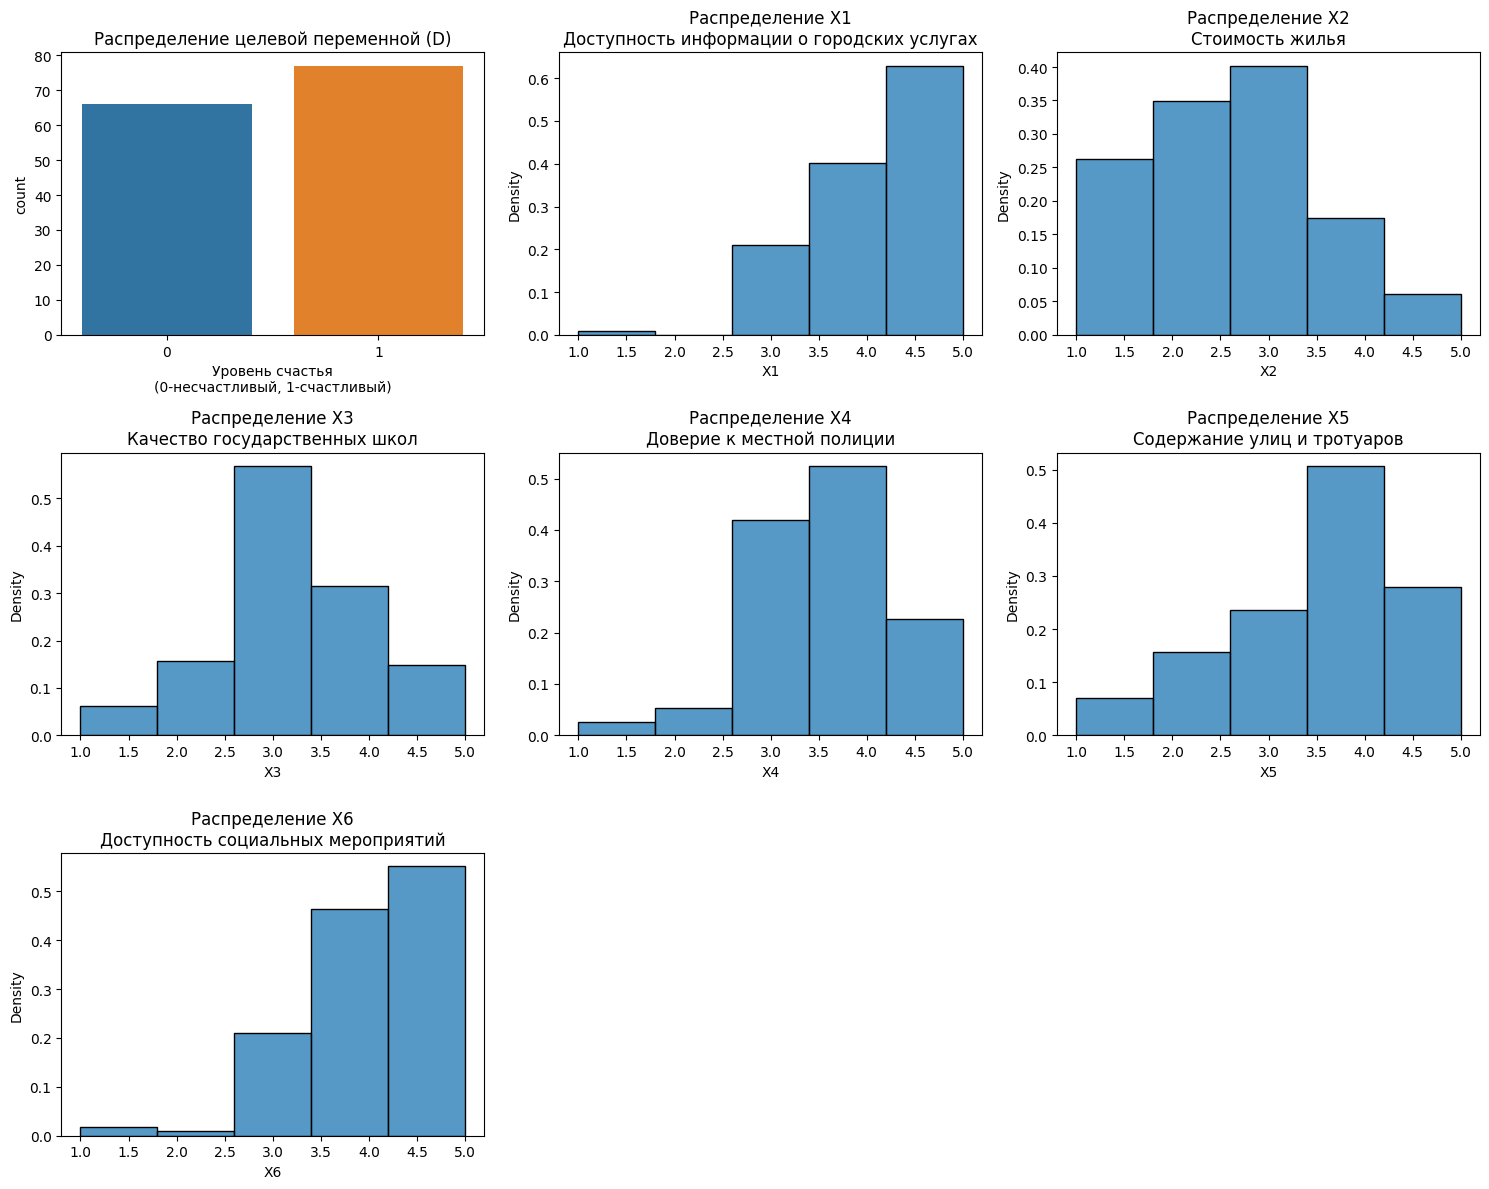

In [6]:
# Визуализация распределения
plt.figure(figsize=(15, 12))

# Распределение целевой переменной
plt.subplot(3, 3, 1)
sns.countplot(data=df, x='D')
plt.title('Распределение целевой переменной (D)')
plt.xlabel('Уровень счастья\n(0-несчастливый, 1-счастливый)')

for i, feature in enumerate(features):
    plt.subplot(3, 3, i+2)
    # Гистограмма
    sns.histplot(df[feature], kde=False, bins=5, stat='density')
    plt.title(f'Распределение {feature}\n{feature_names[feature]}')

plt.tight_layout()
plt.show()

По гистограммам видно, что распределение ни одного из признаков не согласуется с нормальным. Также все признаки имеют разные средние и стандартные отклонения, поэтому требуется стандартизация для использования некоторых методов решения (например, для нейронной сети).

Проведем разделение данных на тестовую и обучающую выборки.

In [19]:
# Разделение на признаки и целевую переменную
X = df.drop('D', axis=1)
y = df['D']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

print(f"\nБаланс классов в обучающей выборке:")
print(y_train.value_counts(normalize=True))

Размер обучающей выборки: (100, 6)
Размер тестовой выборки: (43, 6)

Баланс классов в обучающей выборке:
1    0.54
0    0.46
Name: D, dtype: float64


Как мы видим, баланс классов в данных смещен в пользу 1. Это стоит учитывать при оценке и интерпретации результатов.

Проведем стандартизацию данных.

In [17]:
# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## 3 Решение задачи классификации
### 3.1 Нейронная сеть
В качестве первого метода была выбрана нейронная сеть, многослойный перцептрон.   
Причины выбора:
- Нейросеть может выявлять сложные взаимодействия между признаками, которые линейные методы могут пропустить;
- Гибкость архитектуры;
- Устойчивость к выбросам и шуму.

Были заданы следующие параметры модели: 
- `hidden_layer_sizes=(100, 50)` - 2 слоя, 100 и 50 нейронов - баланс между сложностью и переобучением;
- `activation='relu'` - функция активации, ReLU наиболее эффективна для скрытых слоев (sigmoid и tahn уступают, а Leaky ReLU не требуется в нашем случае);
- `solver='adam'` - оптимизатор по умолчанию;
- `alpha=0.001` - умеренная регуляризация для предотвращения переобучения;
- `max_iter=1000` - количество итераций, 1000 достаточно для сходимости на небольших данных.

In [9]:
# Обучение моделей классификации
print("Метод 1: Нейронная сеть")
nn_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    max_iter=1000,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)
y_pred_nn = nn_model.predict(X_test_scaled)

print("Отчет классификации:")
print(classification_report(y_test, y_pred_nn))

Метод 1: Нейронная сеть
Отчет классификации:
              precision    recall  f1-score   support

           0       0.55      0.60      0.57        20
           1       0.62      0.57      0.59        23

    accuracy                           0.58        43
   macro avg       0.58      0.58      0.58        43
weighted avg       0.58      0.58      0.58        43



Каждое второе предсказание нейронной сети «несчастливый» ошибочно. Модель пропускает около 40% людей, которым нужна помощь. 

Общее качество предсказаний (accuracy) 58%, это довольно плохой результат. Но опираться на него нельзя, так как данный параметр чувствителен к несбалансированности классов, а в исходных данных 54% счастливых и 46% несчастливых.

### 3.2 Дерево решений

В качестве второго метода было выбрано дерево решений, т.к.:
- Признаки имеют дискретные значения от 1 до 5, что отлично подходит для деревьев;
- Встроенная оценка важности признаков показывает, какие факторы наиболее значимы;
- Не требует масштабирования признаков.

Кроме того, оба метода работают с бинарной классификацией.

Были выбраны следующие параметры модели:
- `max_depth=5` - ограничение глубины, 5 - достаточная глубина, предотвращающая переобучение;
- `min_samples_split=10` - минимальное количество примеров для разделения;
- `min_samples_leaf=5` - минимум 5 примеров на класс, предотвращает вырожденные листья с 1-2 примерами.


In [10]:
print("\nМетод 2: Дерево решений")
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Отчет классификации:")
print(classification_report(y_test, y_pred_dt))


Метод 2: Дерево решений
Отчет классификации:
              precision    recall  f1-score   support

           0       0.63      0.85      0.72        20
           1       0.81      0.57      0.67        23

    accuracy                           0.70        43
   macro avg       0.72      0.71      0.70        43
weighted avg       0.73      0.70      0.69        43



Модель в 81% случаев правильно определяет счастливых и находит 85% несчастливых. F-мера является удовлетворительной для обоих классов.\

### 3.3 Визуализация результата дерева решений

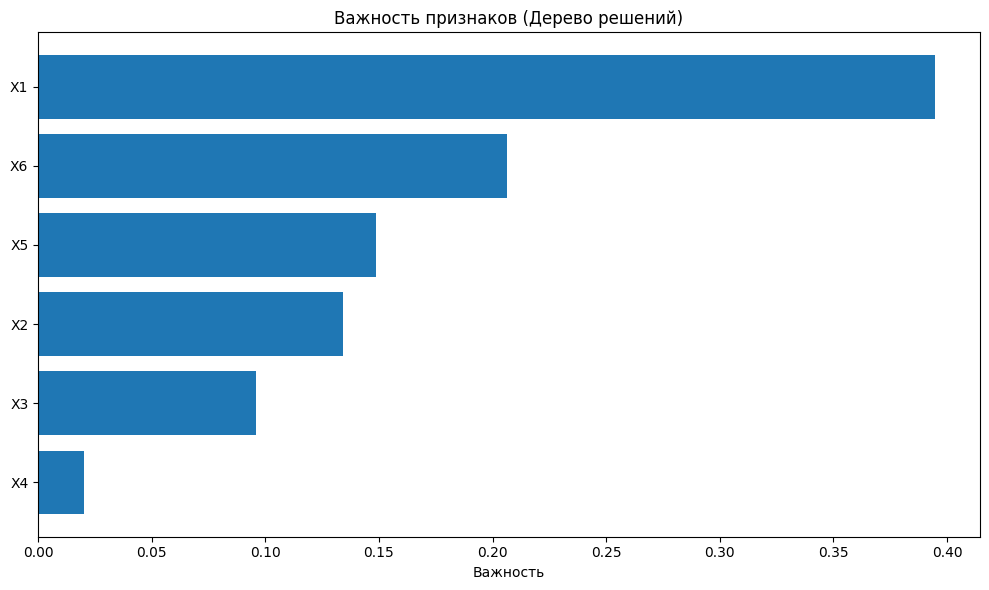

In [11]:
# Визуализация важности признаков
plt.figure(figsize=(10, 6))
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('Важность признаков (Дерево решений)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

Как видно на графике, признак X1 (доступность информации о городских услугах) наиболее значимый, Х6 (доступность социальных мероприятий) менее значим, остальные второстепенны.

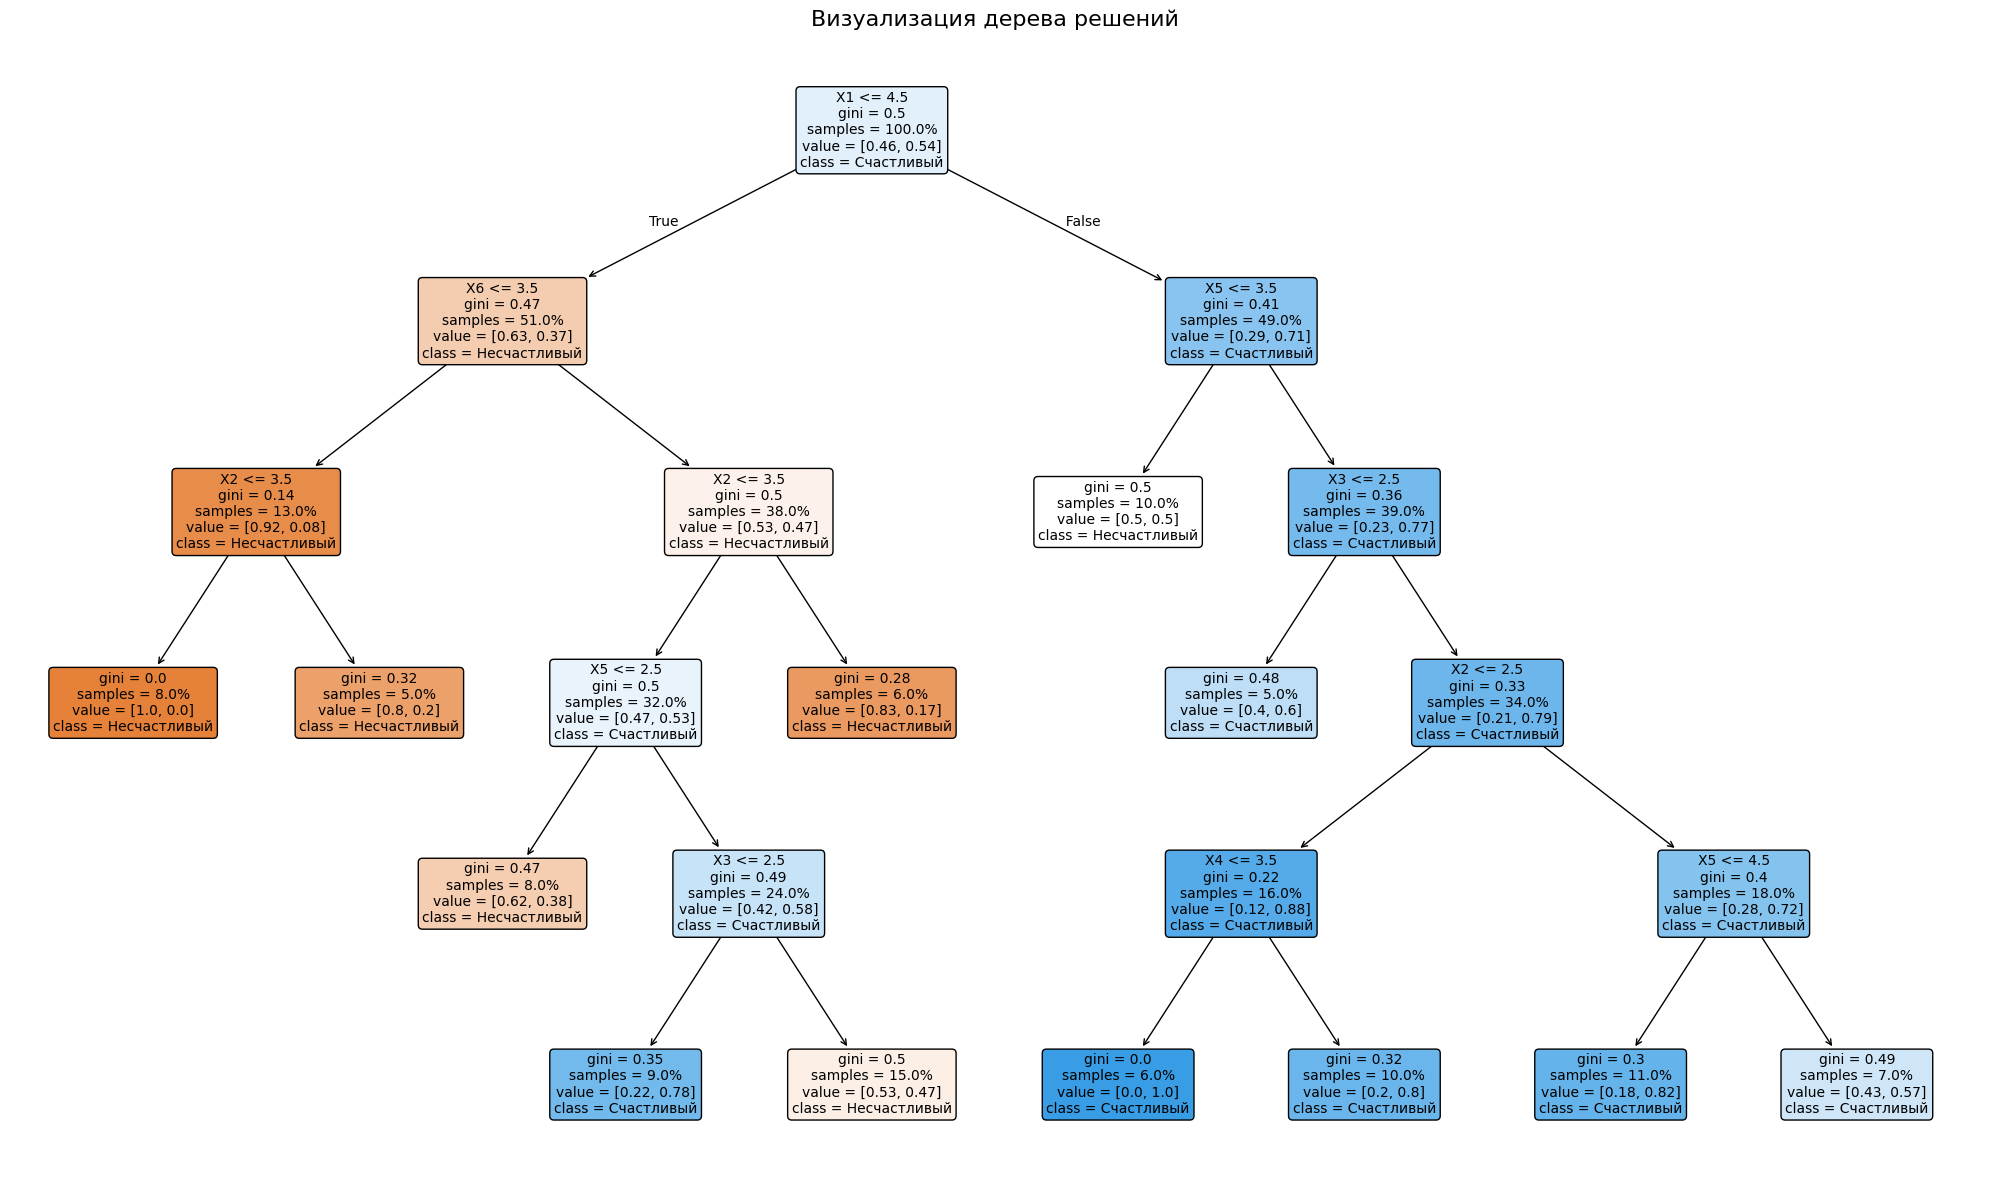

In [12]:
plt.figure(figsize=(20, 12))
plot_tree(dt_model, 
          feature_names=features,
          class_names=['Несчастливый', 'Счастливый'],
          filled=True,
          rounded=True,
          proportion=True,
          fontsize=10,
          precision=2)
plt.title('Визуализация дерева решений', fontsize=16)
plt.tight_layout()
plt.show()

### 3.4 Сравнительный анализ моделей
Cравненим метрики обоих решений. Так как для данного датасета важна способность модели находить несчастливых людей (класс 0), все метрики представлены относительно этого класса.


Сравнительный анализ моделей:
            Метод  Полнота (класс 0)  Точность (класс 0)  F1-мера (класс 0)  \
0  Нейронная сеть               0.60              0.5455             0.5714   
1  Дерево решений               0.85              0.6296             0.7234   

   ROC-AUC  PR-AUC  
0   0.5652  0.5897  
1   0.6880  0.6822  


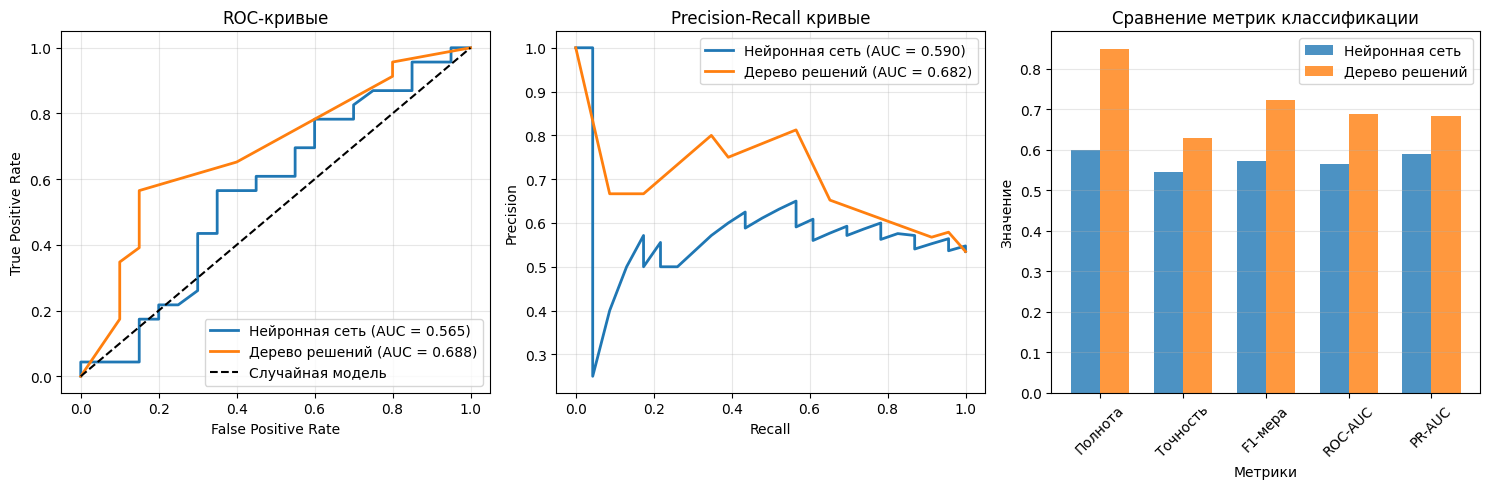

In [13]:
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]
y_pred_proba_nn = nn_model.predict_proba(X_test_scaled)[:, 1]
# ROC-AUC
roc_auc_nn = roc_auc_score(y_test, y_pred_proba_nn)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

# PR-AUC
pr_auc_nn = average_precision_score(y_test, y_pred_proba_nn)
pr_auc_dt = average_precision_score(y_test, y_pred_proba_dt)

# Сравнительный анализ моделей
precision_nn = precision_score(y_test, y_pred_nn, pos_label=0)
recall_nn = recall_score(y_test, y_pred_nn, pos_label=0)
f1_nn = f1_score(y_test, y_pred_nn, pos_label=0)
precision_dt = precision_score(y_test, y_pred_dt, pos_label=0)
recall_dt = recall_score(y_test, y_pred_dt, pos_label=0)
f1_dt = f1_score(y_test, y_pred_dt, pos_label=0)

# Создаем таблицу сравнения
comparison = pd.DataFrame({
    'Метод': ['Нейронная сеть', 'Дерево решений'],
    'Полнота (класс 0)': [recall_nn, recall_dt],
    'Точность (класс 0)': [precision_nn, precision_dt],
    'F1-мера (класс 0)': [f1_nn, f1_dt],
    'ROC-AUC': [roc_auc_nn, roc_auc_dt],
    'PR-AUC': [pr_auc_nn, pr_auc_dt]
})

print("\nСравнительный анализ моделей:")
print(comparison.round(4))

# Визуализация ROC-кривых
plt.figure(figsize=(15, 5))

# ROC-кривые
plt.subplot(1, 3, 1)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_proba_nn)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)

plt.plot(fpr_nn, tpr_nn, label=f'Нейронная сеть (AUC = {roc_auc_nn:.3f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Дерево решений (AUC = {roc_auc_dt:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(True, alpha=0.3)

# Precision-Recall кривые
plt.subplot(1, 3, 2)
precision_nn_curve, recall_nn_curve, _ = precision_recall_curve(y_test, y_pred_proba_nn)
precision_dt_curve, recall_dt_curve, _ = precision_recall_curve(y_test, y_pred_proba_dt)

plt.plot(recall_nn_curve, precision_nn_curve, label=f'Нейронная сеть (AUC = {pr_auc_nn:.3f})', linewidth=2)
plt.plot(recall_dt_curve, precision_dt_curve, label=f'Дерево решений (AUC = {pr_auc_dt:.3f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривые')
plt.legend()
plt.grid(True, alpha=0.3)

# Сравнение метрик
plt.subplot(1, 3, 3)
metrics = ['Полнота', 'Точность', 'F1-мера', 'ROC-AUC', 'PR-AUC']
nn_scores = [recall_nn, precision_nn, f1_nn, roc_auc_nn, pr_auc_nn]
dt_scores = [recall_dt, precision_dt, f1_dt, roc_auc_dt, pr_auc_dt]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, nn_scores, width, label='Нейронная сеть', alpha=0.8)
plt.bar(x + width/2, dt_scores, width, label='Дерево решений', alpha=0.8)

plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение метрик классификации')
plt.xticks(x, metrics, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Для данной задачи дерево решений значительно превосходит нейронную сеть и может быть рекомендовано для практических целей.

---
## 4 Интерпретация результатов
Исследование показывает, что для прогнозирования уровня счастья жителей на основе ограниченных данных дерево решений является оптимальным выбором.
Городским властям Сомервилля следует в первую очередь сосредоточиться на повышении информационной открытости и организации социальных мероприятий. Второстепенными мерами могут быть благоустройство городской инфраструктуры, улучшение качества образования, укрепление доверия к полиции.

---
## 5 Изменение параметров нейронной сети и оценка полученного результата

In [14]:
print("Настройка параметров нейронной сети")

# Эксперимент с различными архитектурами И функциями активации
architectures = [
    (50,),           # Один скрытый слой
    (100, 50),       # Два скрытых слоя
    (100, 75, 50),   # Три скрытых слоя
    (150, 100, 50)   # Три скрытых слоя с большим количеством нейронов
]

activations = ['relu', 'tanh', 'logistic']

results = []

for arch in architectures:
    for activation in activations:
        nn_tuned = MLPClassifier(
            hidden_layer_sizes=arch,
            activation=activation,
            solver='adam',
            alpha=0.001,
            learning_rate='adaptive',
            max_iter=1500,
            random_state=42
        )
        
        nn_tuned.fit(X_train_scaled, y_train)
        y_pred_tuned = nn_tuned.predict(X_test_scaled)
        f = f1_score(y_test, y_pred_tuned, pos_label=0)
        
        results.append({
            'Архитектура': str(arch),
            'Активация': activation,
            'Точность': f
        })
        
        print(f"Архитектура {arch}, активация {activation}: точность = {f:.4f}")

# Выбираем лучшую модель
best_result = max(results, key=lambda x: x['Точность'])
print(f"\nЛучшая комбинация: архитектура {best_result['Архитектура']}, активация {best_result['Активация']}")
print(f"Точность: {best_result['Точность']:.4f}")


Настройка параметров нейронной сети
Архитектура (50,), активация relu: точность = 0.4737
Архитектура (50,), активация tanh: точность = 0.5854
Архитектура (50,), активация logistic: точность = 0.4242
Архитектура (100, 50), активация relu: точность = 0.5714
Архитектура (100, 50), активация tanh: точность = 0.4878
Архитектура (100, 50), активация logistic: точность = 0.4242
Архитектура (100, 75, 50), активация relu: точность = 0.5366
Архитектура (100, 75, 50), активация tanh: точность = 0.5238
Архитектура (100, 75, 50), активация logistic: точность = 0.4375
Архитектура (150, 100, 50), активация relu: точность = 0.5238
Архитектура (150, 100, 50), активация tanh: точность = 0.5455
Архитектура (150, 100, 50), активация logistic: точность = 0.5500

Лучшая комбинация: архитектура (50,), активация tanh
Точность: 0.5854


Были изменены следующие параметры нейронной сети:
- `hidden_layer_sizes` - количество слоев и нейронов в них,
- `activation` - функция активации.
- 
По результатам видно, что `tahn` лучше работает в простых сетях, `relu` - в сетях средней сложности, а `logistic` - в сложных.

Лучшей оказалась нейронная сеть с функцией активации `tahn` и одним слоем с 50 нейронами, однако она все равно уступает по f-мере дереву решений, и, кроме того, 58% недостаточно для практического применения. Это подтверждает, что для малых датасетов простые модели часто эффективнее сложных.